In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gauravaggarwal0911","key":"ccfb853b5120f29f68c6697bcea80973"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d andrewmvd/bone-marrow-cell-classification
!unzip -q bone-marrow-cell-classification.zip -d /content/bone_marrow_15class

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/bone-marrow-cell-classification
License(s): Attribution 4.0 International (CC BY 4.0)
100% 6.46G/6.46G [02:46<00:00, 41.5MB/s]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

DATASET_ROOT = "/content/bone_marrow_15class"
RESULT_DIR = "/content/drive/MyDrive/research/Bone Marrow/Catagorical Results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Dataset root:", DATASET_ROOT)
print("Result folder:", RESULT_DIR)

Dataset root: /content/bone_marrow_15class
Result folder: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results


In [ ]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

all_images = []

for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower().endswith(valid_extensions):
            all_images.append(os.path.join(root, file))

print("Total images found:", len(all_images))

print("\nFirst 20 image paths:")
for p in all_images[:20]:
    print(p)

Total images found: 171374

First 20 image paths:
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00005.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00008.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00004.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00001.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00006.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00003.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00002.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/ABE/ABE_00007.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/LYT/7001-8000/LYT_07784.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/LYT/7001-8000/LYT_07548.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/LYT/7001-8000/LYT_07743.jpg
/content/bone_marrow_15class/bone_marrow_cell_dataset/LYT/7001-8000/LYT_07997.jpg
/content/bone_marrow_15class/bone_marrow_cell_

In [ ]:
import os
import re
import pandas as pd

image_paths = []
class_labels = []

def is_range_folder(folder_name):
    """
    Checks whether folder is like:
    0001-1000, 1001-2000, 2001-3000, etc.
    """
    return bool(re.match(r"^\d+-\d+$", folder_name))


for path in all_images:
    parent_folder = os.path.basename(os.path.dirname(path))
    grandparent_folder = os.path.basename(os.path.dirname(os.path.dirname(path)))

    # If parent folder is only a range like 0001-1000,
    # then actual class is grandparent folder.
    if is_range_folder(parent_folder):
        class_name = grandparent_folder
    else:
        class_name = parent_folder

    image_paths.append(path)
    class_labels.append(class_name)


df_all = pd.DataFrame({
    "image_path": image_paths,
    "class_name": class_labels
})

print(df_all.head())
print("\nTotal images:", len(df_all))
print("Total real classes:", df_all["class_name"].nunique())

print("\nClass distribution:")
print(df_all["class_name"].value_counts())

                                          image_path class_name
0  /content/bone_marrow_15class/bone_marrow_cell_...        ABE
1  /content/bone_marrow_15class/bone_marrow_cell_...        ABE
2  /content/bone_marrow_15class/bone_marrow_cell_...        ABE
3  /content/bone_marrow_15class/bone_marrow_cell_...        ABE
4  /content/bone_marrow_15class/bone_marrow_cell_...        ABE

Total images: 171374
Total real classes: 21

Class distribution:
class_name
NGS    29424
EBO    27395
LYT    26242
ART    19630
PMO    11994
BLA    11973
NGB     9968
PLM     7629
MYB     6557
EOS     5883
MON     4040
NIF     3538
MMZ     3055
PEB     2740
BAS      441
HAC      409
OTH      294
LYI       65
FGC       47
KSC       42
ABE        8
Name: count, dtype: int64


In [ ]:
TOP_N_CLASSES = 8

top_classes = df_all["class_name"].value_counts().head(TOP_N_CLASSES).index.tolist()

df = df_all[df_all["class_name"].isin(top_classes)].copy()
df = df.reset_index(drop=True)

print("Selected top classes:")
for i, cls in enumerate(top_classes):
    print(i, cls, ":", len(df[df["class_name"] == cls]))

print("\nFinal dataset size:", len(df))
print("Number of classes:", df["class_name"].nunique())

Selected top classes:
0 NGS : 29424
1 EBO : 27395
2 LYT : 26242
3 ART : 19630
4 PMO : 11994
5 BLA : 11973
6 NGB : 9968
7 PLM : 7629

Final dataset size: 144255
Number of classes: 8


In [ ]:
# Search for abbreviations.csv inside dataset folder
abbreviation_file = None

for root, dirs, files in os.walk(DATASET_ROOT):
    for file in files:
        if file.lower() == "abbreviations.csv":
            abbreviation_file = os.path.join(root, file)
            break

print("Abbreviation file found:", abbreviation_file)

if abbreviation_file is not None:
    abbreviations_df = pd.read_csv(abbreviation_file, sep=";")
    print(abbreviations_df.head())
else:
    abbreviations_df = None
    print("No abbreviations.csv found. Folder names will be used as class names.")

Abbreviation file found: /content/bone_marrow_15class/abbreviations.csv
  Abbreviation              Meaning
0          ABE  Abnormal eosinophil
1          ART             Artefact
2          BAS             Basophil
3          BLA                Blast
4          EBO         Erythroblast


In [ ]:
class_description_dict = {}

if abbreviations_df is not None:
    # Print column names first
    print("Abbreviation file columns:", abbreviations_df.columns.tolist())

    # Try common column names
    if "Abbreviation" in abbreviations_df.columns and "Meaning" in abbreviations_df.columns:
        class_description_dict = dict(
            zip(
                abbreviations_df["Abbreviation"].astype(str),
                abbreviations_df["Meaning"].astype(str)
            )
        )

    elif "abbreviation" in abbreviations_df.columns and "meaning" in abbreviations_df.columns:
        class_description_dict = dict(
            zip(
                abbreviations_df["abbreviation"].astype(str),
                abbreviations_df["meaning"].astype(str)
            )
        )

    else:
        print("Column names are different. Please check abbreviations_df.head().")
        class_description_dict = {}

# Show dictionary
print("\nClass description dictionary:")
for k, v in list(class_description_dict.items())[:20]:
    print(k, "=", v)

Abbreviation file columns: ['Abbreviation', 'Meaning']

Class description dictionary:
ABE = Abnormal eosinophil
ART = Artefact
BAS = Basophil
BLA = Blast
EBO = Erythroblast
EOS = Eosinophil
FGC = Faggott cell
HAC = Hairy cell
KSC = Smudge cell
LYI = Immature lymphocyte
LYT = Lymphocyte
MMZ = Metamyelocyte
MON = Monocyte
MYB = Myelocyte
NGB = Band neutrophil
NGS = Segmented neutrophil
NIF = Not identifiable
OTH = Other cell
PEB = Proerythroblast
PLM = Plasma cell


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["class_name"])

class_names = list(label_encoder.classes_)
NUM_CLASSES = len(class_names)

# Full class names using abbreviations.csv
class_full_names = []

for class_abbr in class_names:
    full_name = class_description_dict.get(class_abbr, class_abbr)
    class_full_names.append(full_name)

print("\nEncoded classes with full information:")
for i, (abbr, full_name) in enumerate(zip(class_names, class_full_names)):
    count = len(df[df["class_name"] == abbr])
    print(f"{i}: {abbr} -> {full_name} | Images: {count}")

# Save complete class information
class_info_df = pd.DataFrame({
    "label": list(range(NUM_CLASSES)),
    "class_abbreviation": class_names,
    "class_full_name": class_full_names,
    "image_count": [len(df[df["class_name"] == cls]) for cls in class_names]
})

class_info_path = os.path.join(RESULT_DIR, "class_information_15class.csv")
class_info_df.to_csv(class_info_path, index=False)

print("\nClass information saved at:", class_info_path)
print(class_info_df)


Encoded classes with full information:
0: ART -> Artefact | Images: 19630
1: BLA -> Blast | Images: 11973
2: EBO -> Erythroblast | Images: 27395
3: LYT -> Lymphocyte | Images: 26242
4: NGB -> Band neutrophil | Images: 9968
5: NGS -> Segmented neutrophil | Images: 29424
6: PLM -> Plasma cell | Images: 7629
7: PMO -> Promyelocyte | Images: 11994

Class information saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/class_information_15class.csv
   label class_abbreviation       class_full_name  image_count
0      0                ART              Artefact        19630
1      1                BLA                 Blast        11973
2      2                EBO          Erythroblast        27395
3      3                LYT            Lymphocyte        26242
4      4                NGB       Band neutrophil         9968
5      5                NGS  Segmented neutrophil        29424
6      6                PLM           Plasma cell         7629
7      7                PM

In [ ]:
from PIL import Image, UnidentifiedImageError
import os
import pandas as pd
from tqdm import tqdm

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()   # check file integrity

        # Reopen after verify because verify() closes image internally
        with Image.open(path) as img:
            img = img.convert("RGB")
            img.load()

        return True

    except Exception as e:
        return False


print("Original dataframe size:", len(df))

valid_rows = []
corrupt_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    image_path = row["image_path"]

    if is_valid_image(image_path):
        valid_rows.append(row)
    else:
        corrupt_rows.append(row)

df_clean = pd.DataFrame(valid_rows).reset_index(drop=True)
df_corrupt = pd.DataFrame(corrupt_rows).reset_index(drop=True)

print("Valid images:", len(df_clean))
print("Corrupted images removed:", len(df_corrupt))

# Save corrupted file list for record
corrupt_csv_path = os.path.join(RESULT_DIR, "corrupted_images_removed.csv")
df_corrupt.to_csv(corrupt_csv_path, index=False)

print("Corrupted image list saved at:", corrupt_csv_path)

# Replace original df with clean df
df = df_clean.copy()

print("\nClean class distribution:")
print(df["class_name"].value_counts())

Original dataframe size: 144255


100%|██████████| 144255/144255 [02:44<00:00, 879.08it/s]


Valid images: 144255
Corrupted images removed: 0
Corrupted image list saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/corrupted_images_removed.csv

Clean class distribution:
class_name
NGS    29424
EBO    27395
LYT    26242
ART    19630
PMO    11994
BLA    11973
NGB     9968
PLM     7629
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train distribution:")
print(train_df["class_name"].value_counts())

print("\nValidation distribution:")
print(val_df["class_name"].value_counts())

print("\nTest distribution:")
print(test_df["class_name"].value_counts())

Train distribution:
class_name
NGS    20597
EBO    19176
LYT    18369
ART    13741
PMO     8396
BLA     8381
NGB     6978
PLM     5340
Name: count, dtype: int64

Validation distribution:
class_name
NGS    4413
EBO    4109
LYT    3936
ART    2945
PMO    1799
BLA    1796
NGB    1495
PLM    1145
Name: count, dtype: int64

Test distribution:
class_name
NGS    4414
EBO    4110
LYT    3937
ART    2944
PMO    1799
BLA    1796
NGB    1495
PLM    1144
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 8: Clean Data Pipeline with Augmentation
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE

# ------------------------------------------------------------
# Image loading function
# ------------------------------------------------------------
def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    label = tf.cast(label, tf.int32)

    return image, label


# ------------------------------------------------------------
# Data augmentation layer
# ------------------------------------------------------------
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.15)
], name="cell_augmentation")


# ------------------------------------------------------------
# Augmentation function
# This was missing in your code
# ------------------------------------------------------------
def augment_image(image, label):
    image = augmentation(image, training=True)
    return image, label


# ------------------------------------------------------------
# Dataset creation function
# ------------------------------------------------------------
def make_dataset(dataframe, training=False):
    paths = dataframe["image_path"].values
    labels = dataframe["label"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=min(len(dataframe), 10000), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print("Clean dataset pipeline created successfully.")

Clean dataset pipeline created successfully.


In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image min:", tf.reduce_min(images).numpy())
    print("Image max:", tf.reduce_max(images).numpy())
    print("Labels:", labels.numpy()[:10])

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image min: 0.0
Image max: 1.0252411
Labels: [3 0 5 3 0 5 5 3 6 5]


In [ ]:
classes = np.unique(train_df["label"])

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = {
    int(cls): weight for cls, weight in zip(classes, class_weights_values)
}

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(0.9185830725565824), 1: np.float64(1.5060553633217992), 2: np.float64(0.6582316437213183), 3: np.float64(0.6871495454298002), 4: np.float64(1.8088635712238463), 5: np.float64(0.6128198281303102), 6: np.float64(2.3637172284644197), 7: np.float64(1.5033646974749881)}


In [ ]:
def se_block(x, ratio=8):
    filters = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(max(filters // ratio, 4), activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)

    return layers.Multiply()([x, se])


def residual_attention_block(x, filters, stride=1, dropout_rate=0.0):
    shortcut = x

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)

    x = se_block(x, ratio=8)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal"
        )(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("swish")(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)

    return x


def build_bm_ra_cnn_multiclass(input_shape=(224, 224, 3), num_classes=15):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(
        32,
        kernel_size=3,
        strides=1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal"
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("swish")(x)

    x = residual_attention_block(x, 32, stride=1, dropout_rate=0.05)
    x = residual_attention_block(x, 32, stride=1, dropout_rate=0.05)

    x = residual_attention_block(x, 64, stride=2, dropout_rate=0.10)
    x = residual_attention_block(x, 64, stride=1, dropout_rate=0.10)

    x = residual_attention_block(x, 128, stride=2, dropout_rate=0.15)
    x = residual_attention_block(x, 128, stride=1, dropout_rate=0.15)

    x = residual_attention_block(x, 256, stride=2, dropout_rate=0.20)
    x = residual_attention_block(x, 256, stride=1, dropout_rate=0.20)

    x = residual_attention_block(x, 384, stride=2, dropout_rate=0.25)
    x = residual_attention_block(x, 384, stride=1, dropout_rate=0.25)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(
        512,
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.50)(x)

    x = layers.Dense(
        128,
        activation="swish",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.35)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="BM_RA_CNN_15Class")
    return model


model = build_bm_ra_cnn_multiclass(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "BM_RA_CNN_15Class"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 224, 224,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 224, 224,  │      9,216 │ activation_21[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 224, 224,  │      9,216 │ activation_22[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │        160 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_10          │ (None, 1, 1, 32)  │          0 │ dense_24[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Multiply)          │ 32)               │            │ reshape_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 224, 224,  │          0 │ multiply_10[0][0… │
│                     │ 32)               │            │ activation_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 224, 224,  │          0 │ add_10[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 224, 224,  │          0 │ activation_23[0]… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,156,416 (31.11 MB)

 Trainable params: 8,147,008 (31.08 MB)

 Non-trainable params: 9,408 (36.75 KB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseCategoricalAccuracy(name="sparse_accuracy")
    ]
)

In [ ]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image min:", tf.reduce_min(images).numpy())
    print("Image max:", tf.reduce_max(images).numpy())
    print("Labels:", labels.numpy()[:10])

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image min: 0.0
Image max: 1.060474
Labels: [6 6 7 2 5 5 0 3 3 3]


In [ ]:
print("Number of selected classes:", df["label"].nunique())
print("Class names:", class_names)

print("\nClass distribution:")
print(df["class_name"].value_counts())

print("\nLabel distribution:")
print(df["label"].value_counts().sort_index())

assert df["label"].nunique() == TOP_N_CLASSES, "Number of labels does not match TOP_N_CLASSES"
assert df["label"].min() == 0, "Labels should start from 0"
assert df["label"].max() == TOP_N_CLASSES - 1, "Labels should end at TOP_N_CLASSES - 1"

Number of selected classes: 8
Class names: ['ART', 'BLA', 'EBO', 'LYT', 'NGB', 'NGS', 'PLM', 'PMO']

Class distribution:
class_name
NGS    29424
EBO    27395
LYT    26242
ART    19630
PMO    11994
BLA    11973
NGB     9968
PLM     7629
Name: count, dtype: int64

Label distribution:
label
0    19630
1    11973
2    27395
3    26242
4     9968
5    29424
6     7629
7    11994
Name: count, dtype: int64


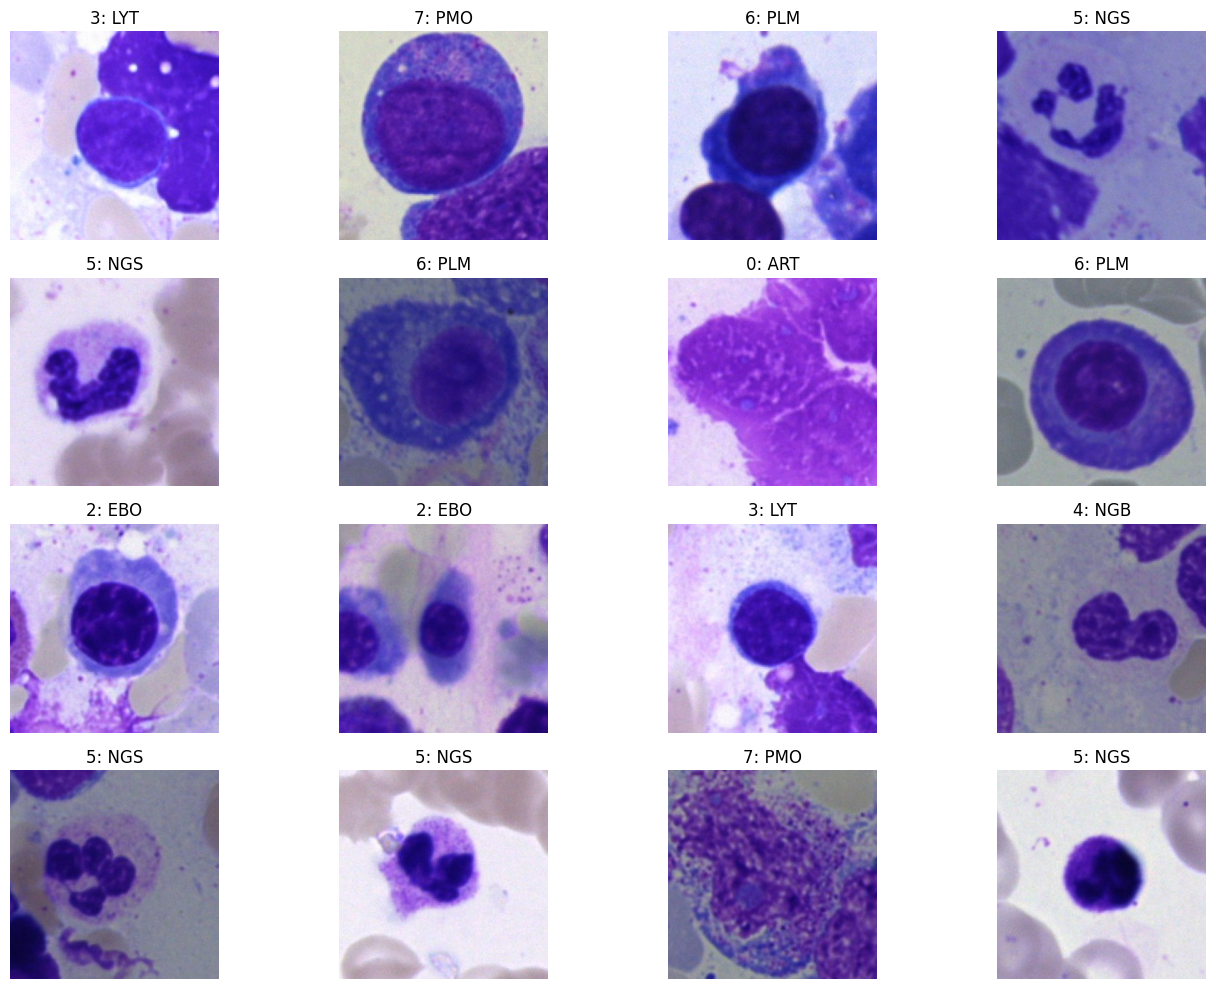

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

plt.figure(figsize=(14, 10))

sample_df = df.sample(16, random_state=42).reset_index(drop=True)

for i in range(16):
    img_path = sample_df.loc[i, "image_path"]
    label = sample_df.loc[i, "label"]
    class_name = sample_df.loc[i, "class_name"]

    img = Image.open(img_path).convert("RGB")

    plt.subplot(4, 4, i + 1)
    plt.imshow(img)
    plt.title(f"{label}: {class_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
best_model_path = os.path.join(RESULT_DIR, "best_BM_RA_CNN_15class.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=12,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.3373 - loss: 1.8156 - sparse_accuracy: 0.3373
Epoch 1: val_accuracy improved from None to 0.68181, saving model to /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/best_BM_RA_CNN_15class.keras

Epoch 1: finished saving model to /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/best_BM_RA_CNN_15class.keras
3156/3156 ━━━━━━━━━━━━━━━━━━━━ 355s 112ms/step - accuracy: 0.4540 - loss: 1.5361 - sparse_accuracy: 0.4540 - val_accuracy: 0.6818 - val_loss: 0.9599 - val_sparse_accuracy: 0.6818 - learning_rate: 3.0000e-04
Epoch 2/20
3155/3156 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6389 - loss: 1.0852 - sparse_accuracy: 0.6389
Epoch 2: val_accuracy improved from 0.68181 to 0.73265, saving model to /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/best_BM_RA_CNN_15class.keras

Epoch 2: finished saving model to /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/best_BM_

In [ ]:
history_df = pd.DataFrame(history.history)

history_csv_path = os.path.join(RESULT_DIR, "training_history_08class.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved at:", history_csv_path)

Training history saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/training_history_08class.csv


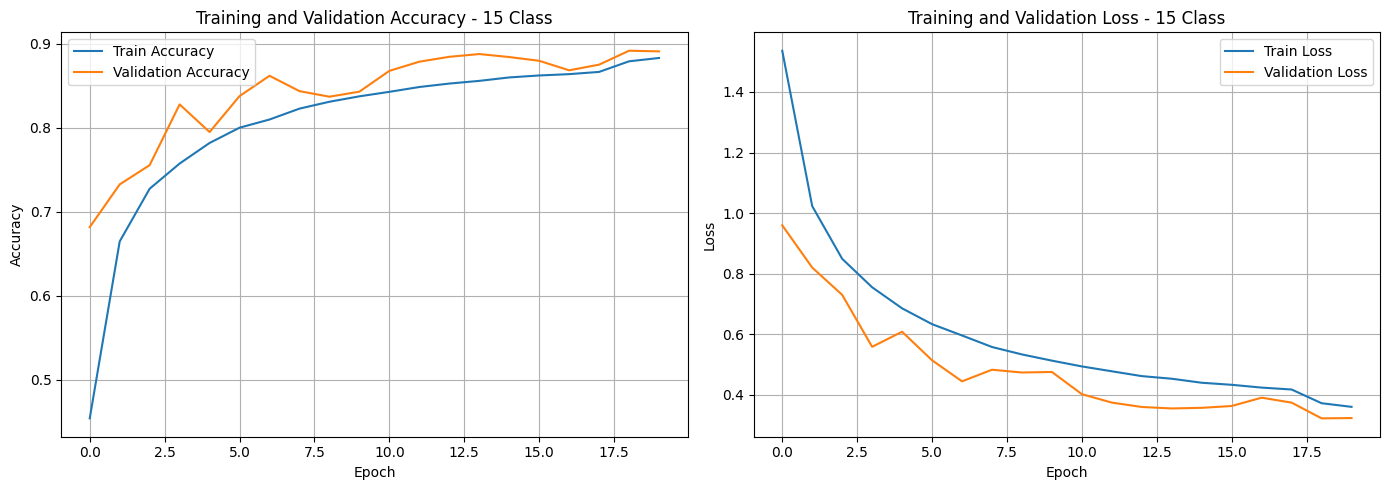

Curve saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/accuracy_loss_curves_15class.png


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy - 15 Class")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss - 15 Class")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

curve_path = os.path.join(RESULT_DIR, "accuracy_loss_curves_15class.png")
plt.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Curve saved at:", curve_path)

In [ ]:
best_model = keras.models.load_model(best_model_path)

test_results = best_model.evaluate(test_ds)

print("Test Results:")
for name, value in zip(best_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

677/677 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.8973 - loss: 0.3148 - sparse_accuracy: 0.8973
Test Results:
loss: 0.3148
compile_metrics: 0.8973


In [ ]:
y_true = []
y_prob = []

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_prob.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

y_pred = np.argmax(y_prob, axis=1)

print("Prediction completed.")

Prediction completed.


In [ ]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_csv_path = os.path.join(RESULT_DIR, "classification_report_08class.csv")
report_df.to_csv(report_csv_path)

print(report_df)
print("Classification report saved at:", report_csv_path)

              precision    recall  f1-score       support
ART            0.939224  0.855639  0.895485   2944.000000
BLA            0.847991  0.869710  0.858714   1796.000000
EBO            0.968907  0.940146  0.954310   4110.000000
LYT            0.905237  0.922022  0.913552   3937.000000
NGB            0.645794  0.924415  0.760385   1495.000000
NGS            0.962641  0.828953  0.890809   4414.000000
PLM            0.823664  0.943182  0.879381   1144.000000
PMO            0.922294  0.956643  0.939154   1799.000000
accuracy       0.897269  0.897269  0.897269      0.897269
macro avg      0.876969  0.905089  0.886474  21639.000000
weighted avg   0.908093  0.897269  0.899385  21639.000000
Classification report saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/classification_report_08class.csv


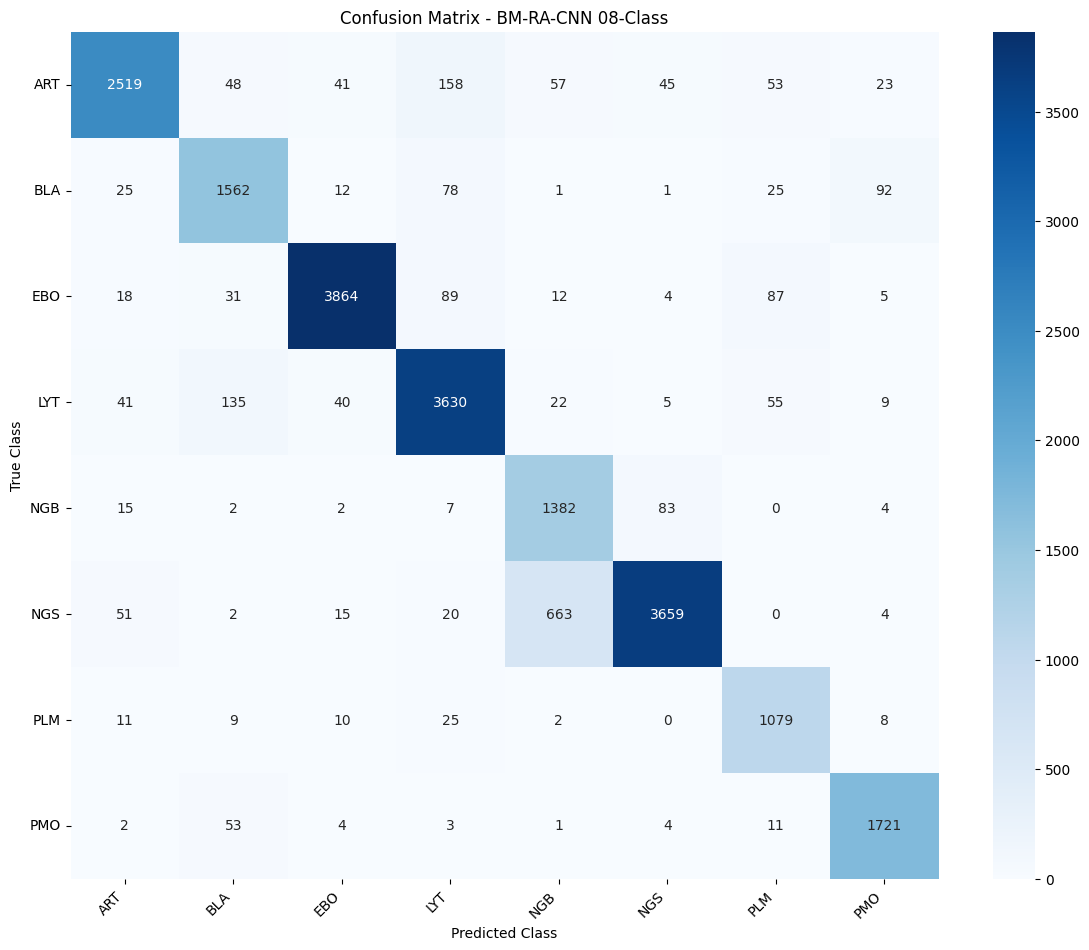

Confusion matrix saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/confusion_matrix_08class.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{name}" for name in class_names],
    columns=[f"Predicted_{name}" for name in class_names]
)

cm_csv_path = os.path.join(RESULT_DIR, "confusion_matrix_08class.csv")
cm_df.to_csv(cm_csv_path)

plt.figure(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - BM-RA-CNN 08-Class")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

cm_png_path = os.path.join(RESULT_DIR, "confusion_matrix_08class.png")
plt.savefig(cm_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved at:", cm_png_path)

In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

try:
    auc_ovr_macro = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro"
    )
except Exception as e:
    auc_ovr_macro = None
    print("AUC could not be calculated:", e)

metrics_df = pd.DataFrame([{
    "Accuracy": accuracy,
    "Macro Precision": precision_macro,
    "Macro Recall": recall_macro,
    "Macro F1-score": f1_macro,
    "Weighted Precision": precision_weighted,
    "Weighted Recall": recall_weighted,
    "Weighted F1-score": f1_weighted,
    "Macro AUC OVR": auc_ovr_macro
}])

metrics_csv_path = os.path.join(RESULT_DIR, "overall_metrics_08class.csv")
metrics_df.to_csv(metrics_csv_path, index=False)

print(metrics_df)
print("Overall metrics saved at:", metrics_csv_path)

   Accuracy  Macro Precision  Macro Recall  Macro F1-score  \
0  0.897269         0.876969      0.905089        0.886474   

   Weighted Precision  Weighted Recall  Weighted F1-score  Macro AUC OVR  
0            0.908093         0.897269           0.899385       0.992672  
Overall metrics saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/overall_metrics_08class.csv


In [ ]:
prediction_df = pd.DataFrame({
    "image_path": test_df["image_path"].values,
    "true_label": y_true,
    "true_class": [class_names[i] for i in y_true],
    "predicted_label": y_pred,
    "predicted_class": [class_names[i] for i in y_pred]
})

for i, class_name in enumerate(class_names):
    prediction_df[f"probability_{class_name}"] = y_prob[:, i]

prediction_csv_path = os.path.join(RESULT_DIR, "test_predictions_08class.csv")
prediction_df.to_csv(prediction_csv_path, index=False)

print(prediction_df.head())
print("Prediction CSV saved at:", prediction_csv_path)

                                          image_path  true_label true_class  \
0  /content/bone_marrow_15class/bone_marrow_cell_...           5        NGS   
1  /content/bone_marrow_15class/bone_marrow_cell_...           6        PLM   
2  /content/bone_marrow_15class/bone_marrow_cell_...           2        EBO   
3  /content/bone_marrow_15class/bone_marrow_cell_...           2        EBO   
4  /content/bone_marrow_15class/bone_marrow_cell_...           4        NGB   

   predicted_label predicted_class  probability_ART  probability_BLA  \
0                5             NGS         0.000376     8.218645e-07   
1                6             PLM         0.000139     8.734037e-06   
2                4             NGB         0.000520     4.715669e-05   
3                2             EBO         0.000288     1.758508e-03   
4                4             NGB         0.000392     4.301420e-06   

   probability_EBO  probability_LYT  probability_NGB  probability_NGS  \
0         0.000004 

In [ ]:
final_model_path = os.path.join(RESULT_DIR, "final_BM_RA_CNN_08class.keras")

best_model.save(final_model_path)

print("Best model saved at:", best_model_path)
print("Final model saved at:", final_model_path)

Best model saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/best_BM_RA_CNN_15class.keras
Final model saved at: /content/drive/MyDrive/research/Bone Marrow/Catagorical Results/final_BM_RA_CNN_08class.keras


In [ ]:
zip_path = "/content/BM_RA_CNN_08class_results.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name="/content/BM_RA_CNN_08class_results",
    format="zip",
    root_dir=RESULT_DIR
)

print("Zipped results saved at:", zip_path)

KeyboardInterrupt: 